<a href="https://colab.research.google.com/github/leenAbdulaziz-glitch/Lost-Child-Finder/blob/main/Training_Lost_Child_Finder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lost Child Finder
---

## Lost Child Detection System using YOLOv8 + ByteTrack

**Project Idea:**
This system is designed to detect and track children and adults in real-time video streams.
It aims to identify when a child becomes separated from their corresponding adult guardian.

**Core Logic:**
1. Detect all persons in each video frame using a YOLOv8 object detection model.
2. Classify detected objects into two categories: Child and Adult.
3. Track each individual using ByteTrack to assign a unique ID over time.
4. Pair each child with the nearest adult when first detected (assumed guardian).
5. Continuously calculate the distance between each child and their assigned adult.

**Alert System:**
- SAFE (🟢): distance ≤ 2.0 m
- WARNING (🟡): 2.0 m < distance ≤ 2.5 m
- ALERT (🔴): distance > 2.5 m → child is lost

## Dataset
- Children vs Adults (2024) : Roboflow | 999 images | [Link](https://universe.roboflow.com/a-4euhx/children-vs-adults-yolo-my3ct)
- Children vs Adults (2025) : Roboflow | 797 images | [Link](https://universe.roboflow.com/aghababa/children-vs-adults-yolo-nwudf)

In [ ]:
!pip install ultralytics roboflow supervision opencv-python -q

zsh:1: command not found: pip


In [ ]:
import time
import warnings
from collections import defaultdict
import cv2
import numpy as np
from ultralytics import YOLO
import supervision as sv
import imageio
from IPython.display import Image, display, Video
warnings.filterwarnings("ignore")

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="u3MhbecKJgDPA72y5geC")
project = rf.workspace("a-4euhx").project("children-vs-adults-yolo-my3ct")
dataset = project.version(4).download("yolov8")
print("Dataset:", dataset.location)

loading Roboflow workspace...


loading Roboflow project...


Dataset: /Users/user/Desktop/Lost-Child-Finder/Children-vs-Adults-yolo-4


## Training

In [ ]:
"""
# Device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

# Train
model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=75,
    imgsz=640,
    batch=32,
    device=device,
    workers=8,
    cache=True,
    patience=20,
    name="child_finder_v2-2"
)
"""

In [ ]:
import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

# Model already trained — load directly
model = YOLO("/Users/user/Desktop/Lost-Child-Finder/runs/detect/child_finder_v2-2/weights/best.pt")
print("Model loaded:", model.names)

Device: mps
Model loaded: {0: 'Adult', 1: 'Child'}


## Training Results

In [ ]:
print("===== TRAINING RESULTS (50 epochs — M1 Max) =====")
training = {
    "mAP50":     0.843,
    "mAP50-95":  0.626,
    "Precision": 0.801,
    "Recall":    0.777,
}
for k, v in training.items():
    print(f"  {k:<12}: {v:.3f}")
print("=================================================")

===== TRAINING RESULTS (50 epochs — M1 Max) =====
  mAP50       : 0.843
  mAP50-95    : 0.626
  Precision   : 0.801
  Recall      : 0.777


## System Code — LostChildFinder

In [ ]:
COLOR_CHILD  = (0,   200, 255)
COLOR_ADULT  = (50,  220,  80)
COLOR_ALERT  = (0,    40, 230)
COLOR_BG     = (20,   20,  20)

def center(box):
    x1, y1, x2, y2 = box
    return np.array([(x1+x2)/2, (y1+y2)/2])

def box_height(box):
    return max(box[3]-box[1], 1)

def pixel_to_meters(px_dist, ref_h):
    return px_dist / (ref_h + 1e-6) * 3.0

def draw_rounded_rect(img, x1, y1, x2, y2, color, radius=8, thickness=2):
    cv2.line(img, (x1+radius,y1), (x2-radius,y1), color, thickness)
    cv2.line(img, (x1+radius,y2), (x2-radius,y2), color, thickness)
    cv2.line(img, (x1,y1+radius), (x1,y2-radius), color, thickness)
    cv2.line(img, (x2,y1+radius), (x2,y2-radius), color, thickness)
    cv2.ellipse(img,(x1+radius,y1+radius),(radius,radius),180, 0,90,color,thickness)
    cv2.ellipse(img,(x2-radius,y1+radius),(radius,radius),270, 0,90,color,thickness)
    cv2.ellipse(img,(x1+radius,y2-radius),(radius,radius), 90, 0,90,color,thickness)
    cv2.ellipse(img,(x2-radius,y2-radius),(radius,radius),  0, 0,90,color,thickness)

def put_label(img, text, x, y, color, bg=COLOR_BG, scale=0.55, thickness=1):
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw,th),bl = cv2.getTextSize(text,font,scale,thickness)
    cv2.rectangle(img,(x-3,y-th-4),(x+tw+3,y+bl),bg,-1)
    cv2.putText(img,text,(x,y),font,scale,color,thickness,cv2.LINE_AA)

def draw_alert_banner(img, msg, frame_w):
    overlay = img.copy()
    cv2.rectangle(overlay,(0,0),(frame_w,44),(0,0,180),-1)
    img[:] = cv2.addWeighted(overlay,0.82,img,0.18,0)
    font = cv2.FONT_HERSHEY_DUPLEX
    tw,_ = cv2.getTextSize(msg,font,0.75,2)[:2]
    cv2.putText(img,msg,((frame_w-tw[0])//2,30),font,0.75,(255,255,255),2,cv2.LINE_AA)


class LostChildFinder:
    def __init__(self, model_path, threshold_meters=2.5, fps=25.0):
        print(f"[Model] Loading {model_path} ...")
        self.model     = YOLO(model_path)
        self.threshold_m = threshold_meters
        self.fps       = fps
        self.pairs     = {}
        self.separation_start = {}
        print("[Model] Ready ✓")

    def _detect(self, frame):
        results = self.model(frame, verbose=False, imgsz=1280, conf=0.20, iou=0.45)[0]
        children, adults = [], []
        for box in results.boxes:
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            if conf < 0.20: continue
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            name = self.model.names.get(cls_id,"").lower()
            if "child" in name: children.append([x1,y1,x2,y2,conf])
            else:               adults.append([x1,y1,x2,y2,conf])
        return children, adults

    def _assign_pairs(self, children, adults):
        for cid, cbox in children:
            if cid in self.pairs or not adults: continue
            c_center = center(cbox)
            best_aid = min(adults, key=lambda a: np.linalg.norm(c_center-center(a[1])))
            self.pairs[cid] = best_aid[0]

    def process_video(self, video_path, output_path):
        self.pairs = {}
        self.separation_start = {}
        cap = cv2.VideoCapture(video_path)
        fw  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        fh  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS) or self.fps
        writer = imageio.get_writer(output_path, fps=fps)
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret: break
            frame_idx += 1
            t = frame_idx / fps
            boxes_c, boxes_a = self._detect(frame)

            def to_ids(boxes):
                return [(i, b[:4]) for i, b in enumerate(boxes)]

            children_ids = to_ids(boxes_c)
            adults_ids   = to_ids(boxes_a)
            adults_dict  = {aid: ab for aid, ab in adults_ids}
            self._assign_pairs(children_ids, adults_ids)

            separations = {}
            for cid, cbox in children_ids:
                aid = self.pairs.get(cid)
                if aid is None or aid not in adults_dict: continue
                abox = adults_dict[aid]
                px   = np.linalg.norm(center(cbox)-center(abox))
                dm   = pixel_to_meters(px, box_height(abox))
                al   = dm > self.threshold_m
                if al:
                    if cid not in self.separation_start: self.separation_start[cid]=t
                else:
                    self.separation_start.pop(cid,None)
                separations[cid] = (dm, al, abox)

            for aid, abox in adults_ids:
                x1,y1,x2,y2 = abox
                draw_rounded_rect(frame,x1,y1,x2,y2,COLOR_ADULT)
                put_label(frame,f"Adult #{aid}",x1,y1-4,COLOR_ADULT)

            for cid, cbox in children_ids:
                x1,y1,x2,y2 = cbox
                if cid in separations:
                    dm,al,abox = separations[cid]
                    color = COLOR_ALERT if al else COLOR_CHILD
                    label = f"LOST #{cid} | {dm:.1f}m" if al else f"Child #{cid} | {dm:.1f}m"
                    ax1,ay1,ax2,ay2 = abox
                    cv2.line(frame,((x1+x2)//2,(y1+y2)//2),((ax1+ax2)//2,(ay1+ay2)//2),color,2)
                else:
                    color,label = COLOR_CHILD,f"Child #{cid}"
                draw_rounded_rect(frame,x1,y1,x2,y2,color)
                put_label(frame,label,x1,y1-4,color)

            lost_now = sum(1 for v in separations.values() if v[1])
            if lost_now:
                draw_alert_banner(frame,f"⚠  ALERT: {lost_now} CHILD SEPARATED!  ⚠",fw)

            writer.append_data(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB))

        cap.release()
        writer.close()
        print("DONE ✔", output_path)

## Evaluation

In [ ]:
metrics = model.val(
    data="/Users/user/Desktop/Lost-Child-Findeer/Children-vs-Adults-yolo-4/data.yaml",
    imgsz=640,
    conf=0.25,
    iou=0.6,
    plots=True
)

print("\n===== VALIDATION RESULTS =====")
print("mAP50    :", round(metrics.box.map50, 3))
print("mAP50-95 :", round(metrics.box.map, 3))
print("Precision:", round(metrics.box.mp, 3))
print("Recall   :", round(metrics.box.mr, 3))

print("\n===== PER-CLASS =====")
for i, name in model.names.items():
    print(f"{name}: P={round(metrics.box.p[i],3)} R={round(metrics.box.r[i],3)} F1={round(metrics.box.f1[i],3)}")

Ultralytics 8.4.52 🚀 Python-3.14.2 torch-2.11.0 CPU (Apple M1 Max)


Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 153.1±65.8 MB/s, size: 49.3 KB)


val: Scanning /Users/user/Desktop/Lost-Child-Findeer/Children-vs-Adults-yolo-4/valid/labels.cache... 102 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 102/102 4.1Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 14% ━╸────────── 1/7 8.5s/it 2.6s<51.2s

...

                 Adult         78         81      0.763      0.913      0.841      0.606


                 Child         65         70      0.779        0.8      0.769      0.567


Speed: 0.3ms preprocess, 148.7ms inference, 0.0ms loss, 0.2ms postprocess per image


Results saved to /Users/user/Desktop/Lost-Child-Finder/runs/detect/val-3



===== VALIDATION RESULTS =====
mAP50    : 0.805
mAP50-95 : 0.587
Precision: 0.771
Recall   : 0.857

===== PER-CLASS =====
Adult: P=0.763 R=0.913 F1=0.831
Child: P=0.779 R=0.8 F1=0.789


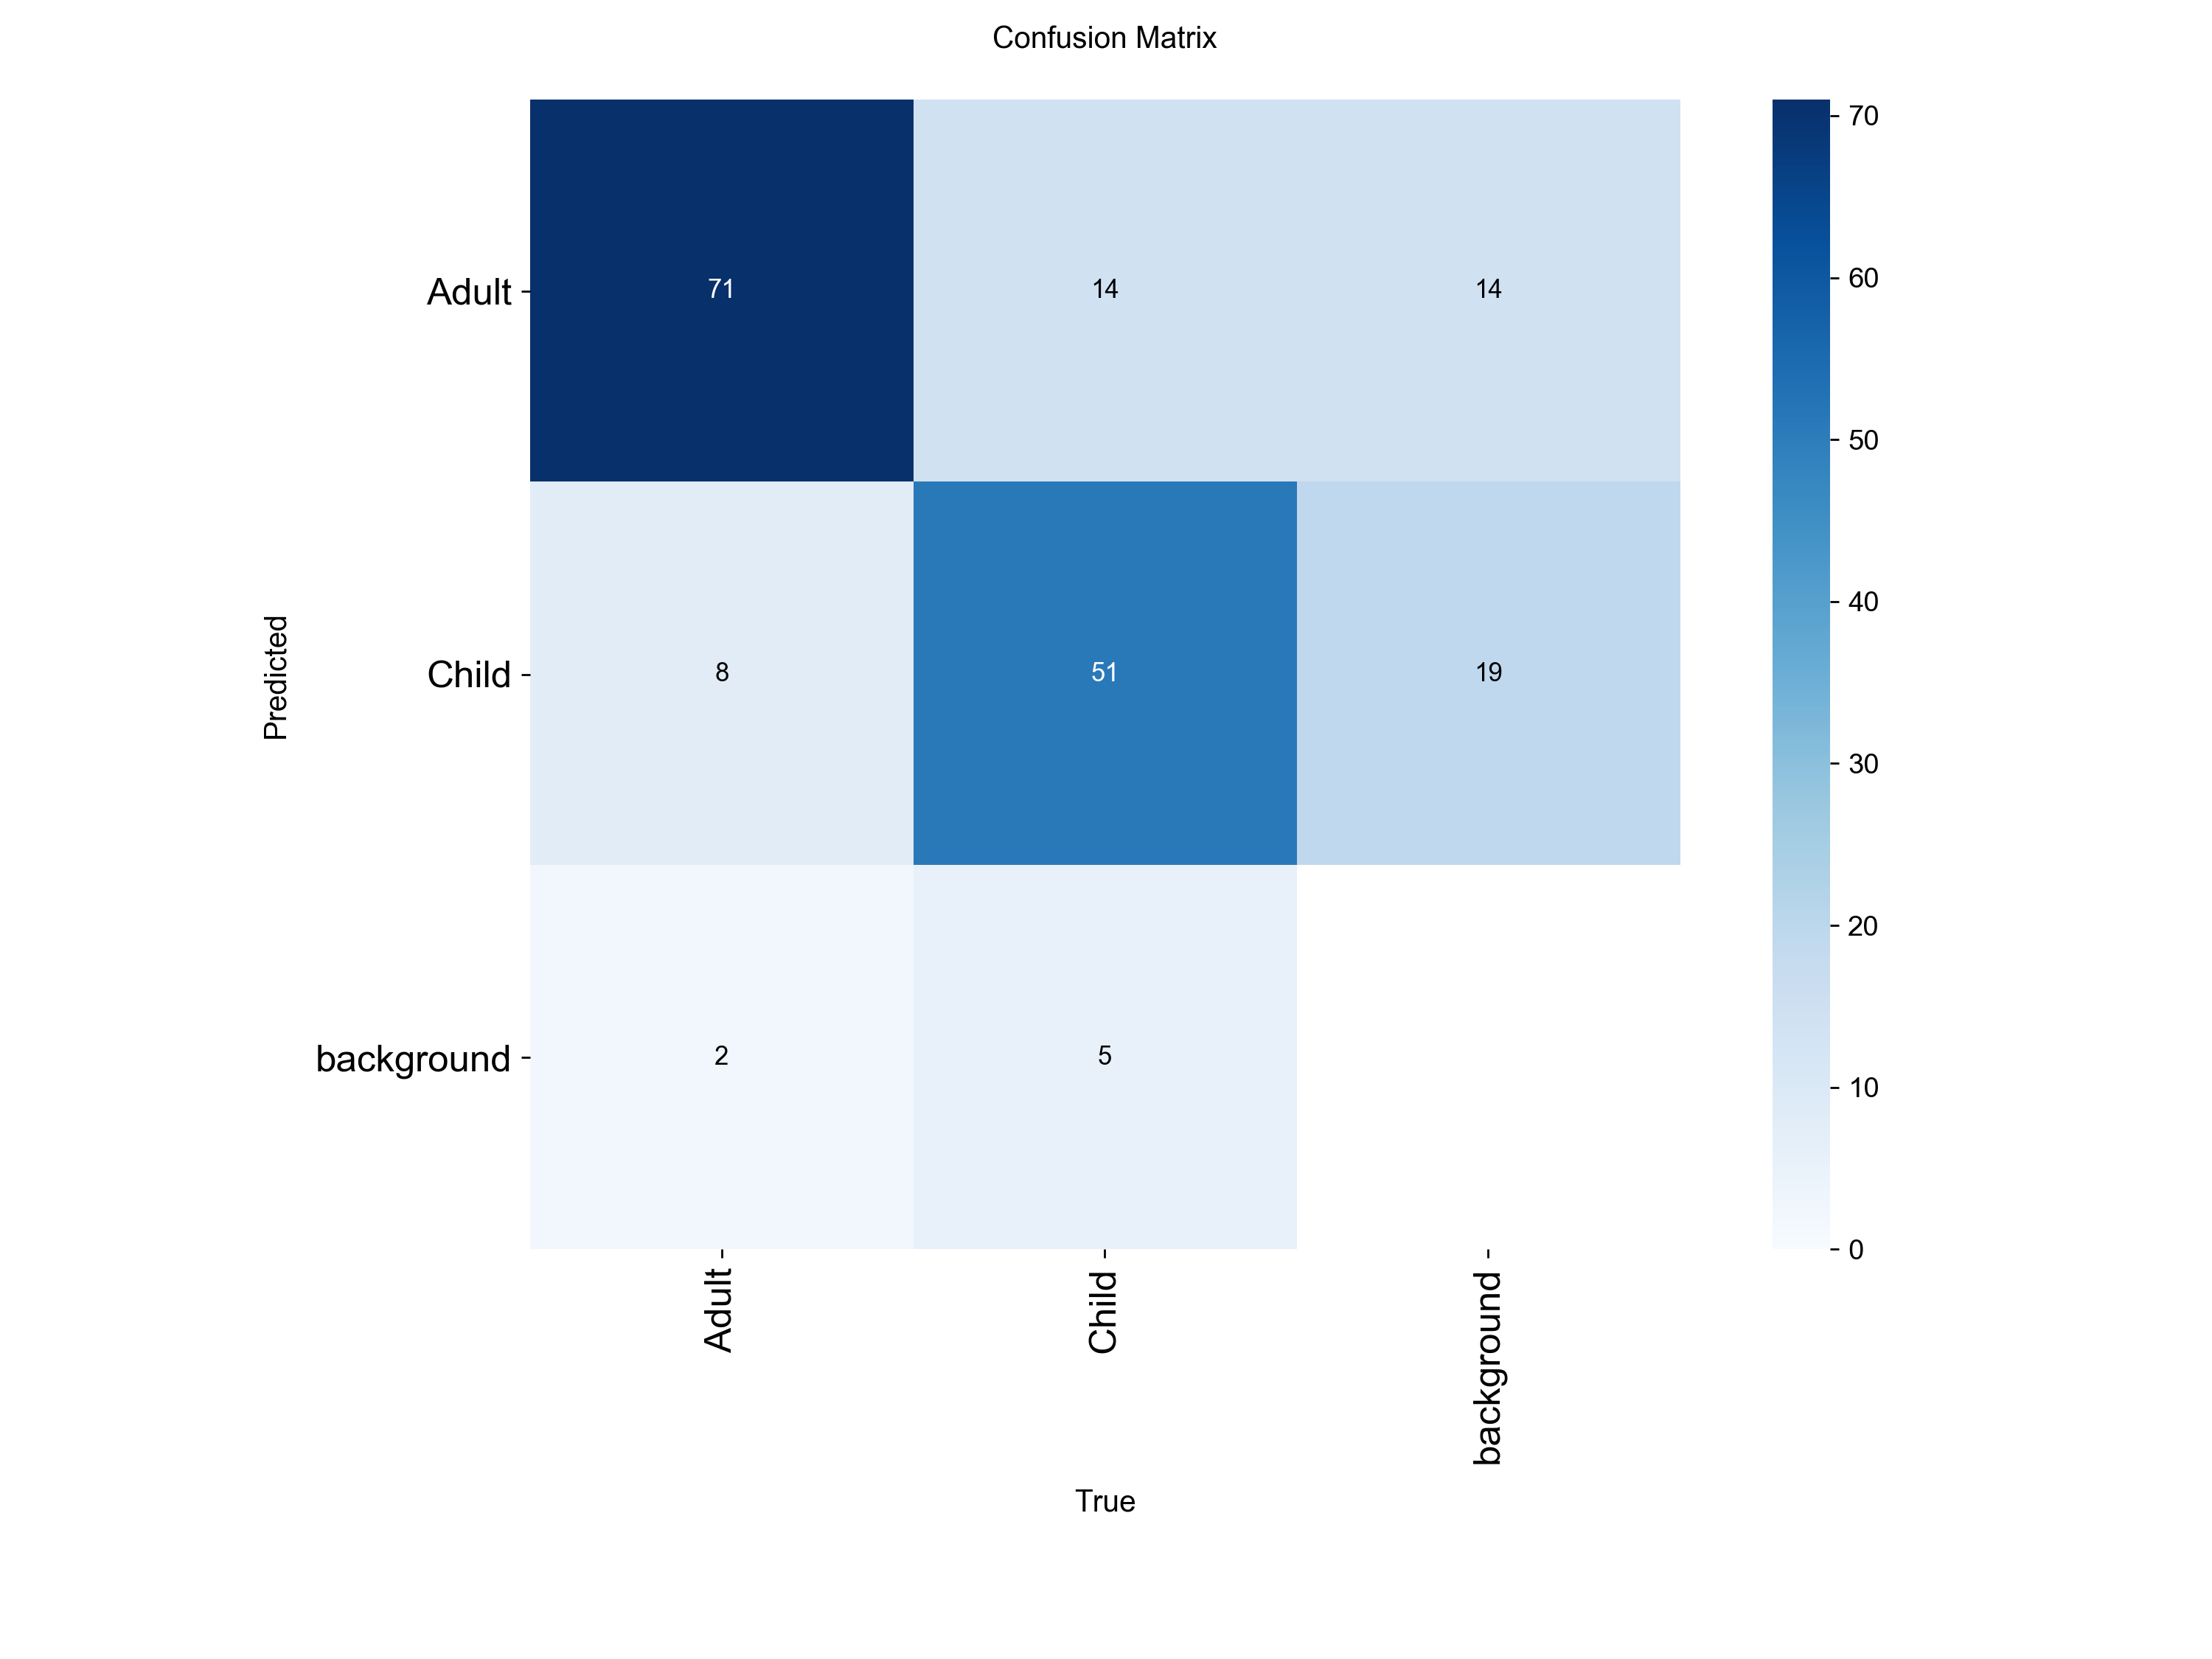

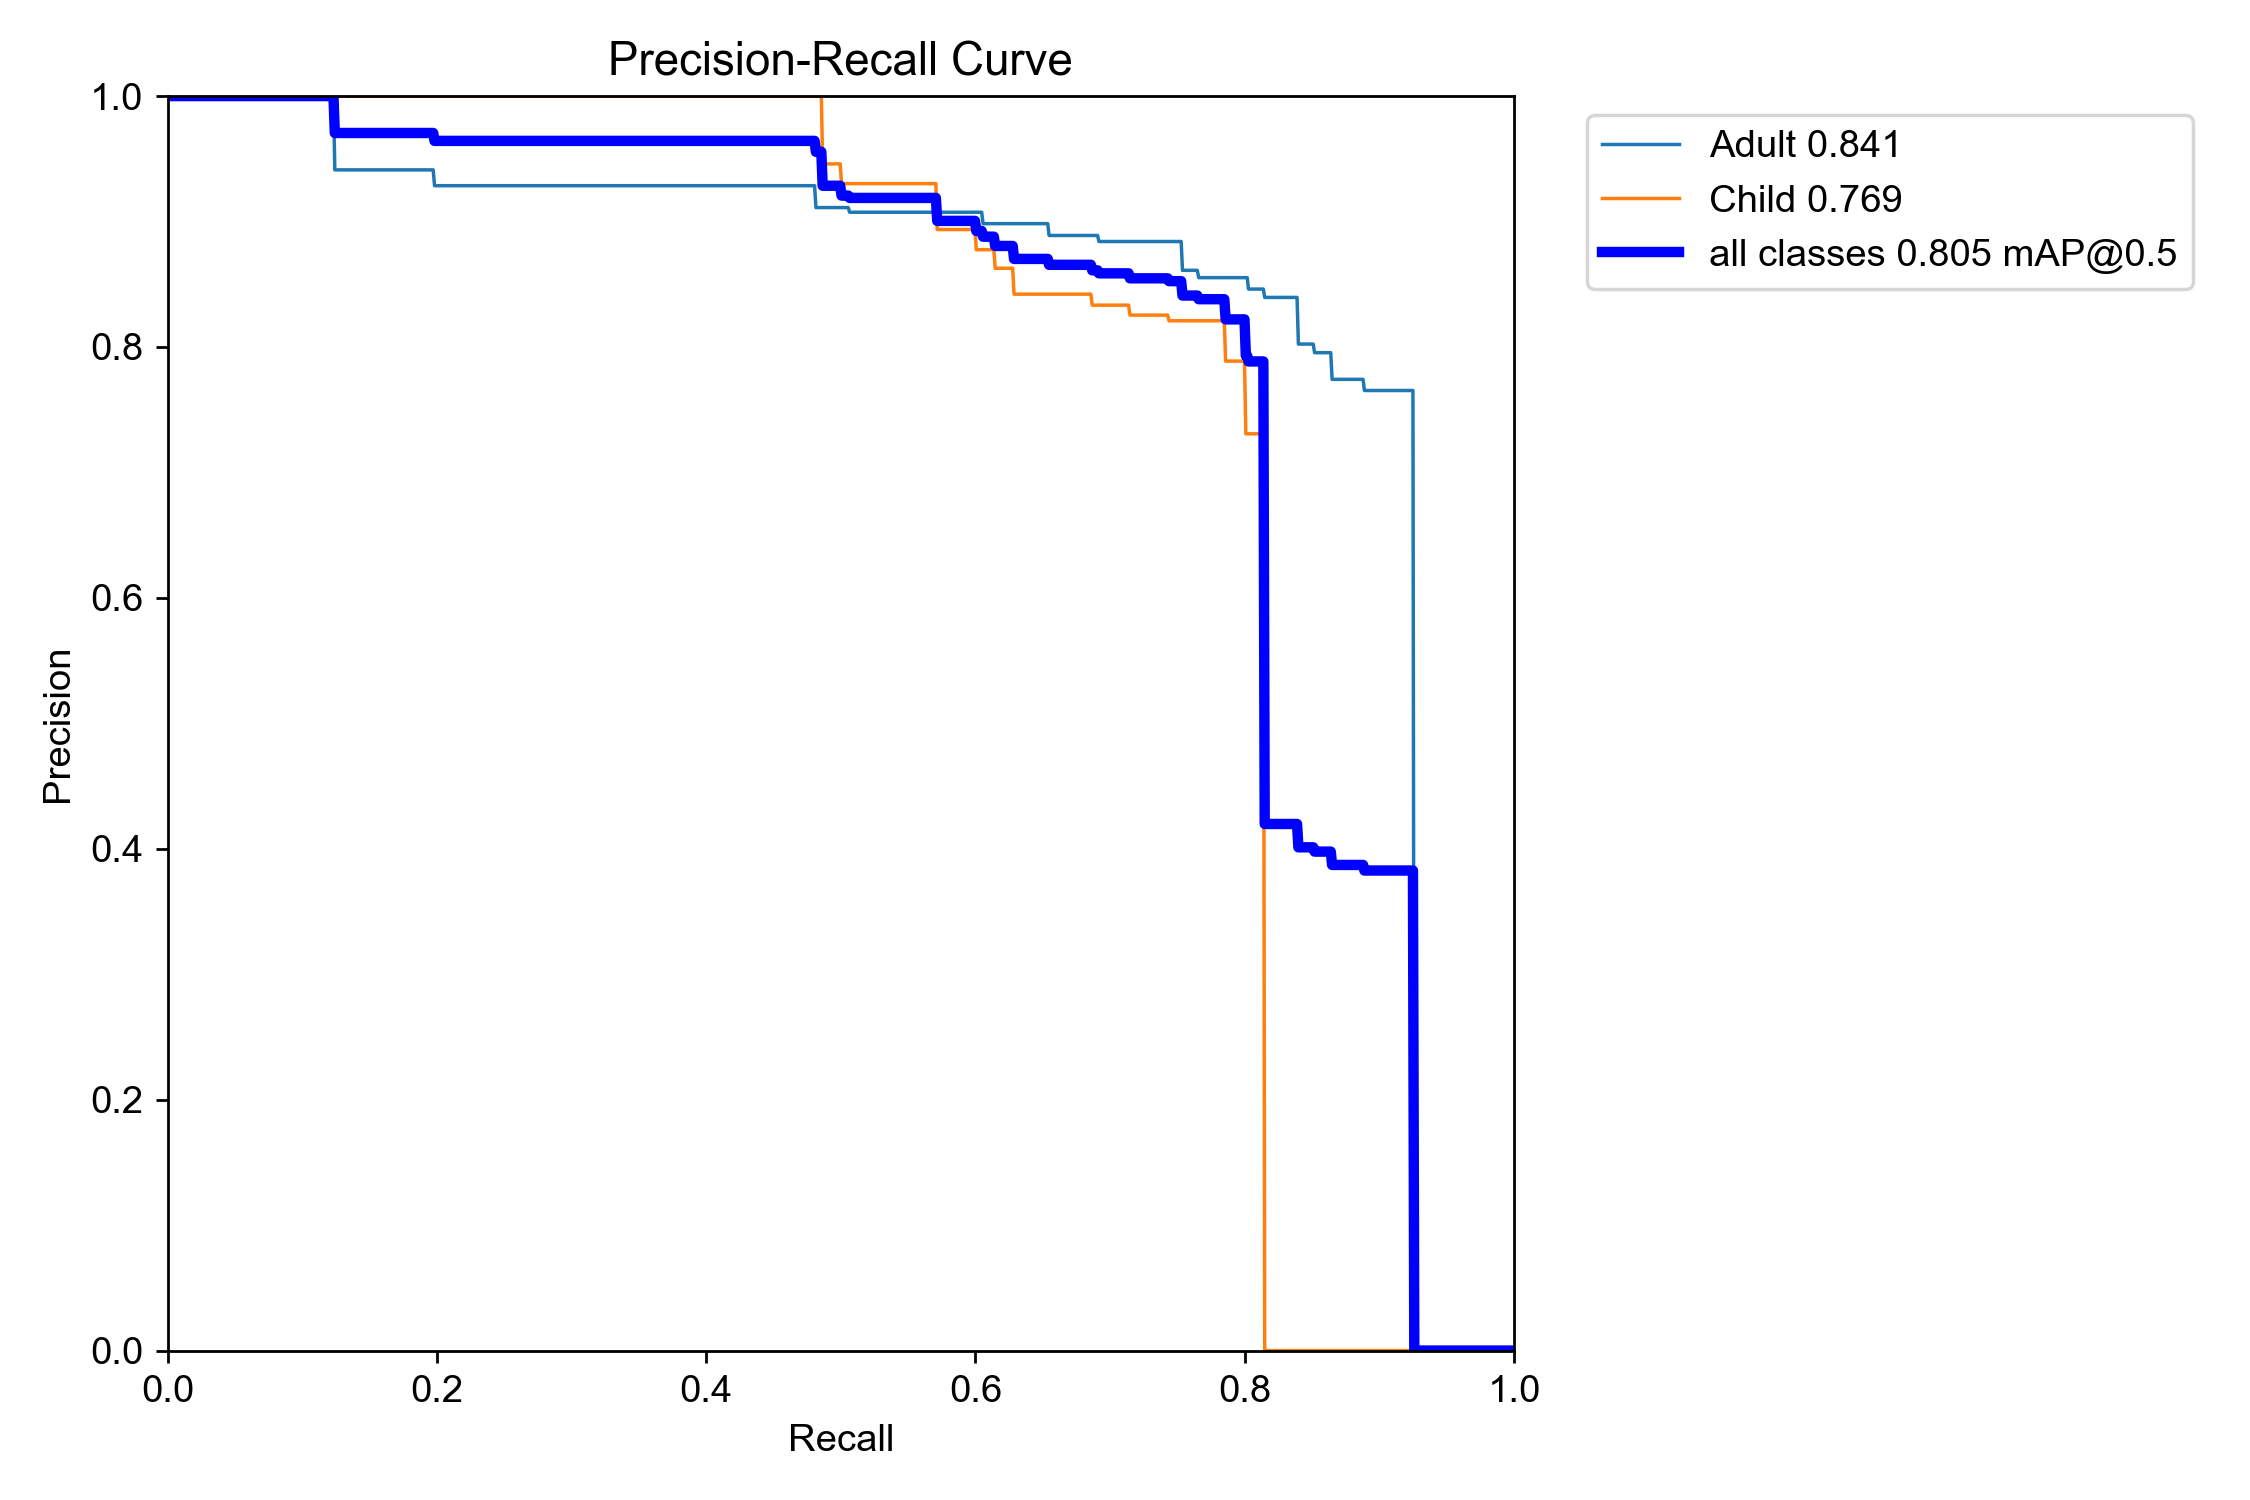

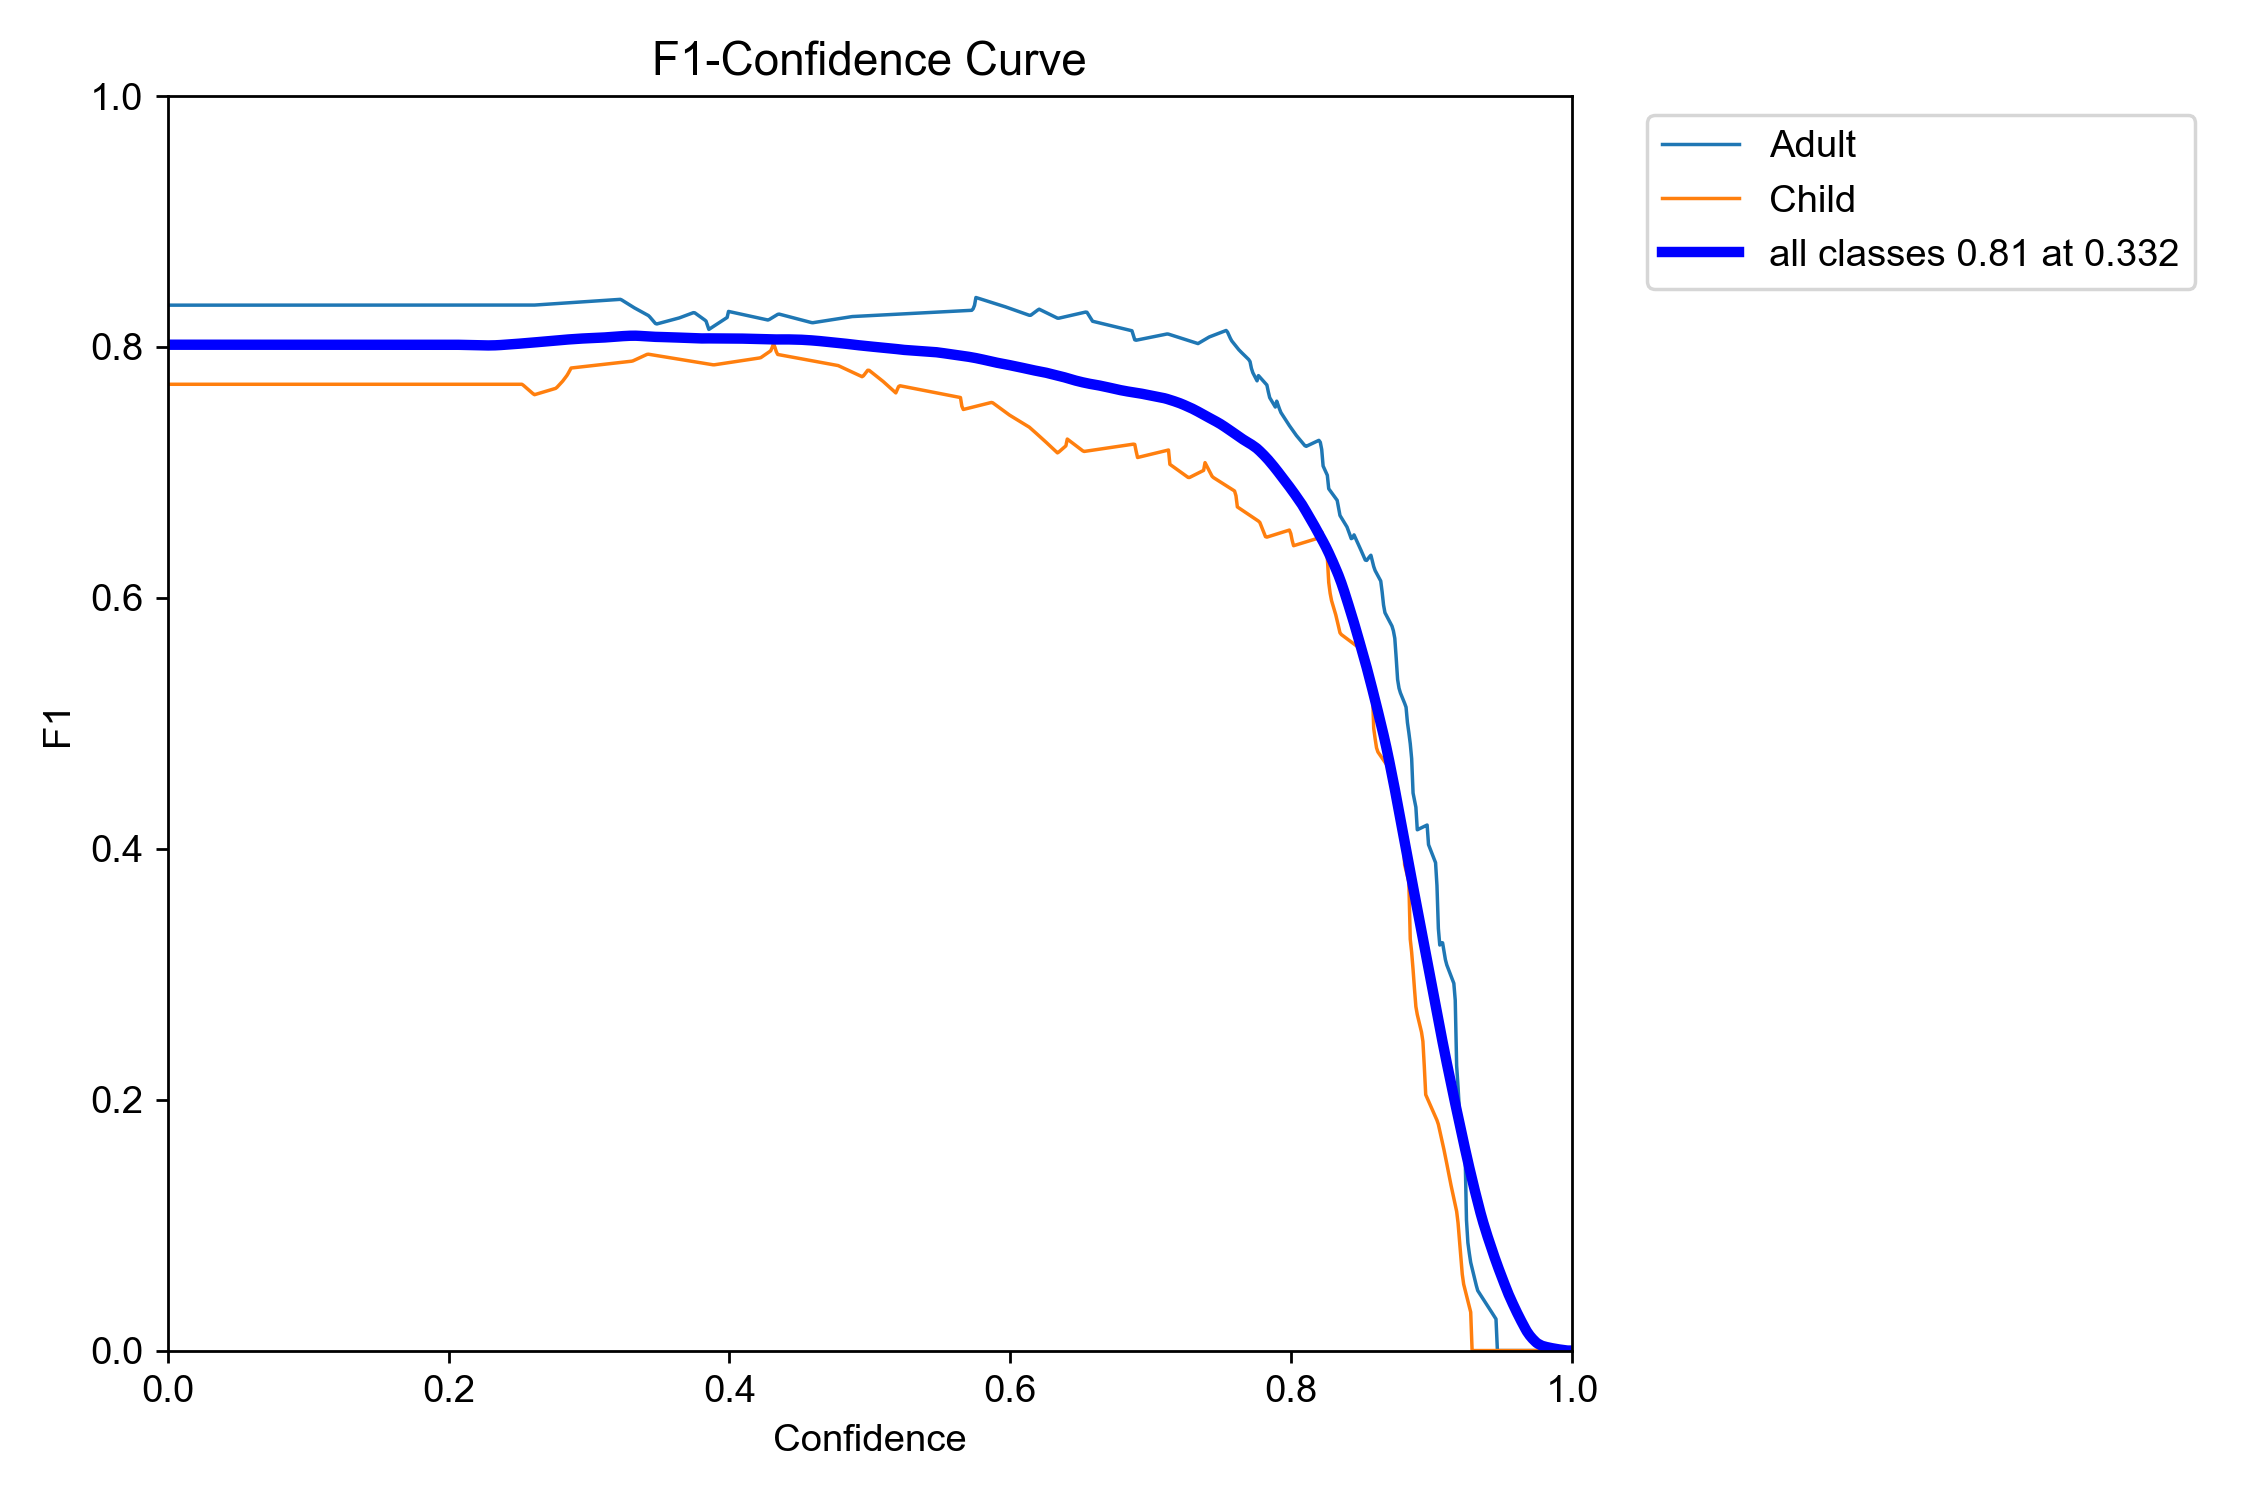

In [ ]:
import os
path = str(metrics.save_dir)
for plot in ["confusion_matrix.png", "BoxPR_curve.png", "BoxF1_curve.png"]:
    if os.path.exists(f"{path}/{plot}"):
        display(Image(f"{path}/{plot}"))

## Demo

Demo: [Google Drive Link](https://drive.google.com/drive/folders/1s5FeLKw9REpY6cIBpYBThi4W1oqj5sgR?usp=drive_link)